In [42]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string
from dateutil import parser

Pulling Data from Database

In [43]:
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

In [44]:
with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {pg_schema};'))

In [45]:
with engine.begin() as conn: # Done with echo=False
    data_airports = conn.execute(text(f'''
                               SELECT * FROM mart_faa_stats; 
                                '''))
    data_flights = conn.execute(text(f'''
                               SELECT * FROM mart_rout_stats;    
                                '''))
    #data_flights_inter_select = conn.execute(text(f'''
                               #SELECT * FROM mart_rout_stats_inter_select;    
                                #'''))
    data_weather = conn.execute(text(f'''
                               SELECT * FROM mart_selected_faa_stats_weather; 
                                '''))    

### Let's create a dataframe out of that
df_airports = pd.DataFrame(data_airports.all()) 
df_flights = pd.DataFrame(data_flights.all())
#df_flights_inter_select = pd.DataFrame(data_flights_inter_select.all())
df_weather = pd.DataFrame(data_weather.all())

Working with Data 

In [46]:
display(df_airports.head())
display(df_airports.info())

,faa,city,country,numer_of_unique_dep_connections,numer_of_unique_arr_connections,total_planed_dep,total_planed_arr,total_canceled_dep,total_canceled_arr,total_diverted_dep,total_diverted_arr,total_actual_dep,total_actual_arr
0,ATL,Atlanta,United States,147,5,53236,4320,982,82,122,6,52254,4238
1,DEN,Denver,United States,157,5,45694,3923,2786,165,141,4,42908,3758
2,DTW,Detroit,United States,90,5,19751,2904,516,75,32,2,19235,2829
3,JFK,New York,United States,65,5,21892,3436,378,36,66,3,21514,3400
4,LAX,Los Angeles,United States,90,5,31001,5196,695,96,74,9,30306,5100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   faa                              6 non-null      object
 1   city                             6 non-null      object
 2   country                          6 non-null      object
 3   numer_of_unique_dep_connections  6 non-null      int64 
 4   numer_of_unique_arr_connections  6 non-null      int64 
 5   total_planed_dep                 6 non-null      int64 
 6   total_planed_arr                 6 non-null      int64 
 7   total_canceled_dep               6 non-null      int64 
 8   total_canceled_arr               6 non-null      int64 
 9   total_diverted_dep               6 non-null      int64 
 10  total_diverted_arr               6 non-null      int64 
 11  total_actual_dep                 6 non-null      int64 
 12  total_actual_arr                 6 non-n

None

In [47]:
display(df_flights.head())
display(df_flights.info())

,origin,origin_city,origin_country,flight_date,hour_of_sched_dep,dest,dest_city,dest_country,total_planed_flights_on_rout,unique_airlines_on_rout,unique_planes_on_rout,avg_actual_elapsed_time_on_rout,avg_arr_delay,max_arr_delay,min_arr_delay,total_canceled_on_rout,total_diverted_on_rout
0,ATL,Atlanta,United States,2022-12-01,0 days 09:00:00,ABE,Allentown,United States,1,1,1,0 days 01:55:00,-1 days +23:49:00,-1 days +23:49:00,-1 days +23:49:00,0,0
1,ATL,Atlanta,United States,2022-12-01,0 days 15:00:00,ABE,Allentown,United States,1,1,1,0 days 01:58:00,0 days 00:02:00,0 days 00:02:00,0 days 00:02:00,0,0
2,ATL,Atlanta,United States,2022-12-01,0 days 19:00:00,ABE,Allentown,United States,1,1,1,0 days 02:11:00,0 days 00:13:00,0 days 00:13:00,0 days 00:13:00,0,0
3,ATL,Atlanta,United States,2022-12-02,0 days 09:00:00,ABE,Allentown,United States,1,1,1,0 days 01:54:00,-1 days +23:49:00,-1 days +23:49:00,-1 days +23:49:00,0,0
4,ATL,Atlanta,United States,2022-12-02,0 days 15:00:00,ABE,Allentown,United States,1,1,1,0 days 01:58:00,-1 days +23:58:00,-1 days +23:58:00,-1 days +23:58:00,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181306 entries, 0 to 181305
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype          
---  ------                           --------------   -----          
 0   origin                           181306 non-null  object         
 1   origin_city                      181306 non-null  object         
 2   origin_country                   181306 non-null  object         
 3   flight_date                      181306 non-null  object         
 4   hour_of_sched_dep                181306 non-null  timedelta64[ns]
 5   dest                             181306 non-null  object         
 6   dest_city                        181306 non-null  object         
 7   dest_country                     181306 non-null  object         
 8   total_planed_flights_on_rout     181306 non-null  int64          
 9   unique_airlines_on_rout          181306 non-null  int64          
 10  unique_planes_on_rout           

None

In [48]:
display(df_weather.head())
display(df_weather.info())

,faa,flight_date,numer_of_unique_dep_connections,total_planed_dep,total_canceled_dep,total_diverted_dep,total_actual_dep,numer_of_unique_arr_connections,total_planed_arr,total_canceled_arr,...,dewpoint_c,humidity_perc,precipitation_mm,snow_mm,wind_direction,wind_speed_kmh,wind_peakgust_kmh,pressure_hpa,condition_code,weather_condition
0,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-2.6,41.0,0.0,None,110,9.4,None,1030.6,3,Cloudy
1,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-4.3,30.0,0.0,None,150,11.2,None,1030.0,1,Clear
2,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-4.8,28.0,0.0,None,150,13.0,None,1029.7,1,Clear
3,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-6.8,24.0,0.0,None,160,9.4,None,1029.9,2,Fair
4,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-6.7,26.0,0.0,None,160,5.4,None,1030.1,2,Fair


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   faa                              8928 non-null   object        
 1   flight_date                      8928 non-null   object        
 2   numer_of_unique_dep_connections  8928 non-null   int64         
 3   total_planed_dep                 8928 non-null   int64         
 4   total_canceled_dep               8928 non-null   int64         
 5   total_diverted_dep               8928 non-null   int64         
 6   total_actual_dep                 8928 non-null   int64         
 7   numer_of_unique_arr_connections  8928 non-null   int64         
 8   total_planed_arr                 8928 non-null   int64         
 9   total_canceled_arr               8928 non-null   int64         
 10  total_diverted_arr               8928 non-null   int64      

None

Weather classification by airport

In [78]:
airports = ['ATL','DEN','DTW','JFK','LAX','ORD']
color_mapping = {
 'ATL': '#1f77b4', # blue
 'DEN': '#ff7f0e', # orange
 'DTW': "#2A782A", # green
 'JFK': '#d62728', # red
 'LAX': '#9467bd', # purple
 'ORD': '#8c564b'  # brown
}

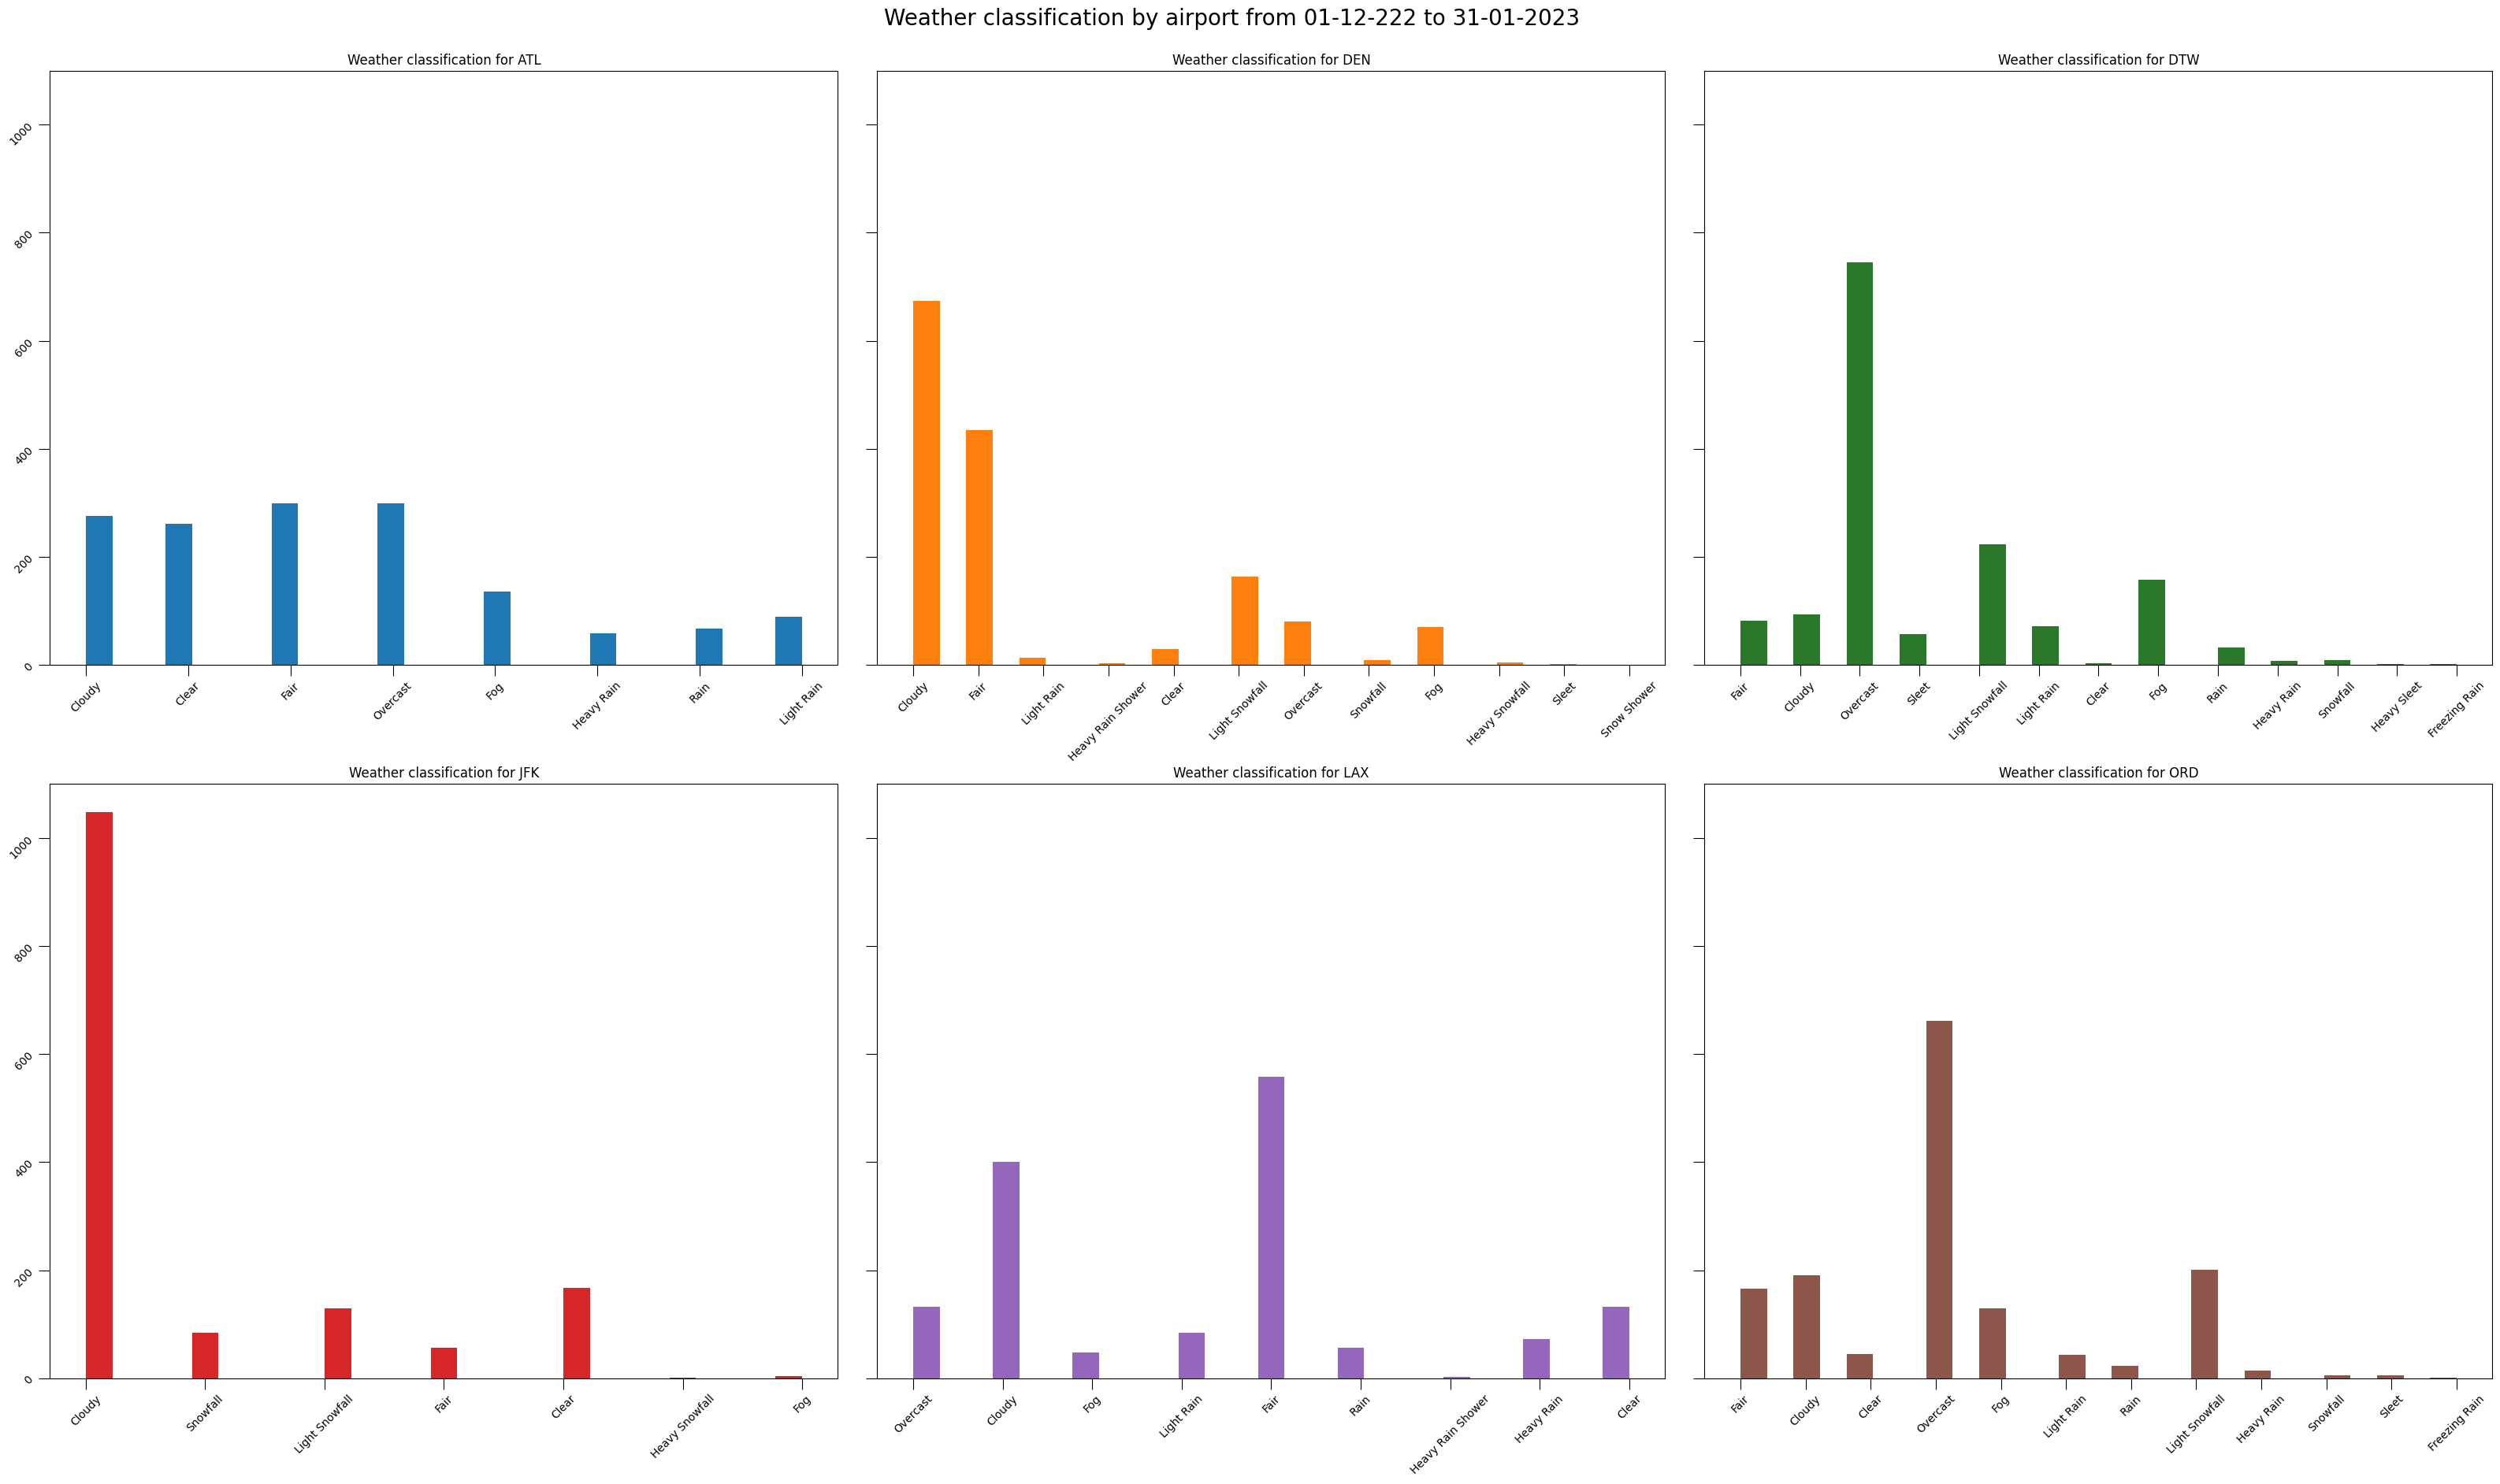

In [79]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
i = 0
plt.suptitle('Weather classification by airport from 01-12-222 to 31-01-2023', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[df_weather['faa'] == x]
        ax[a][b].hist(x=df_int['weather_condition'], bins = 27, color = color_mapping[x])
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Weather classification for {x}')
        display()
        i += 1

In [51]:
!pip install python-dateutil

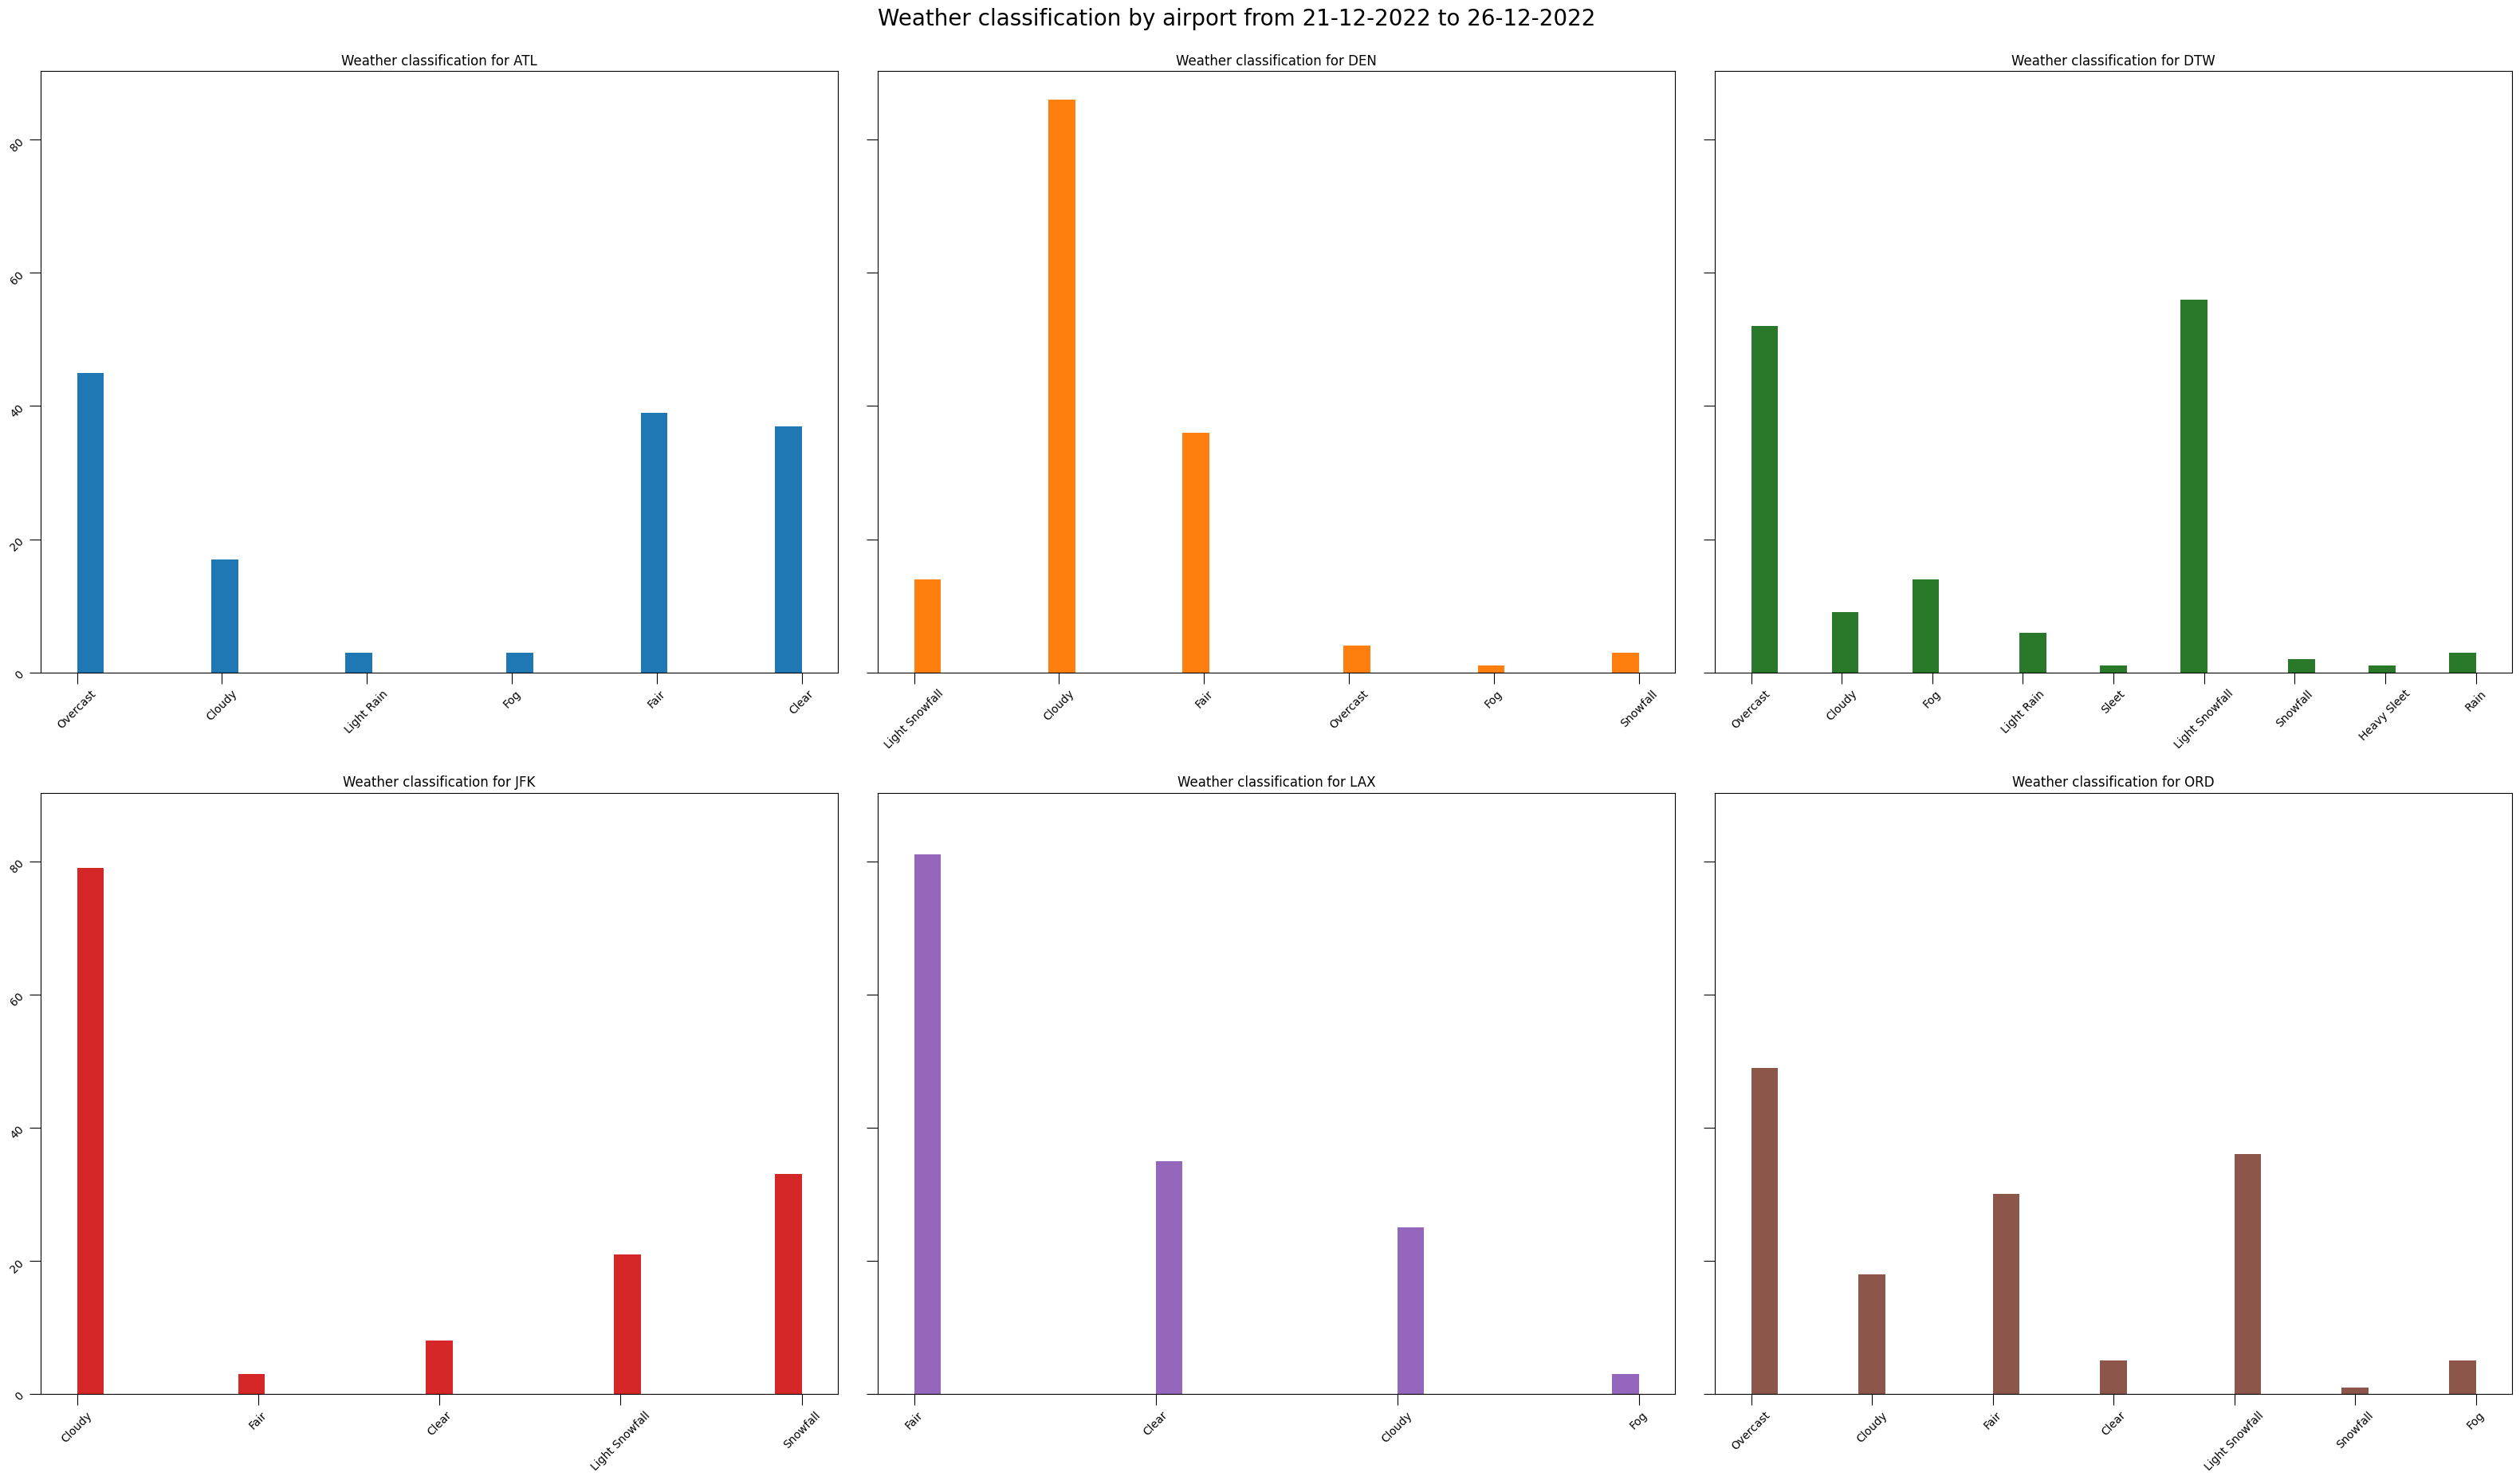

In [80]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
#plt.ylim(0,1000)
i = 0
start_date = '2022-12-21'
end_date = '2022-12-26'
plt.suptitle('Weather classification by airport from 21-12-2022 to 26-12-2022', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
        ax[a][b].hist(x=df_int['weather_condition'], bins = 27, color = color_mapping[x])
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Weather classification for {x}')
        display()
        i += 1

Wind speeds by airport

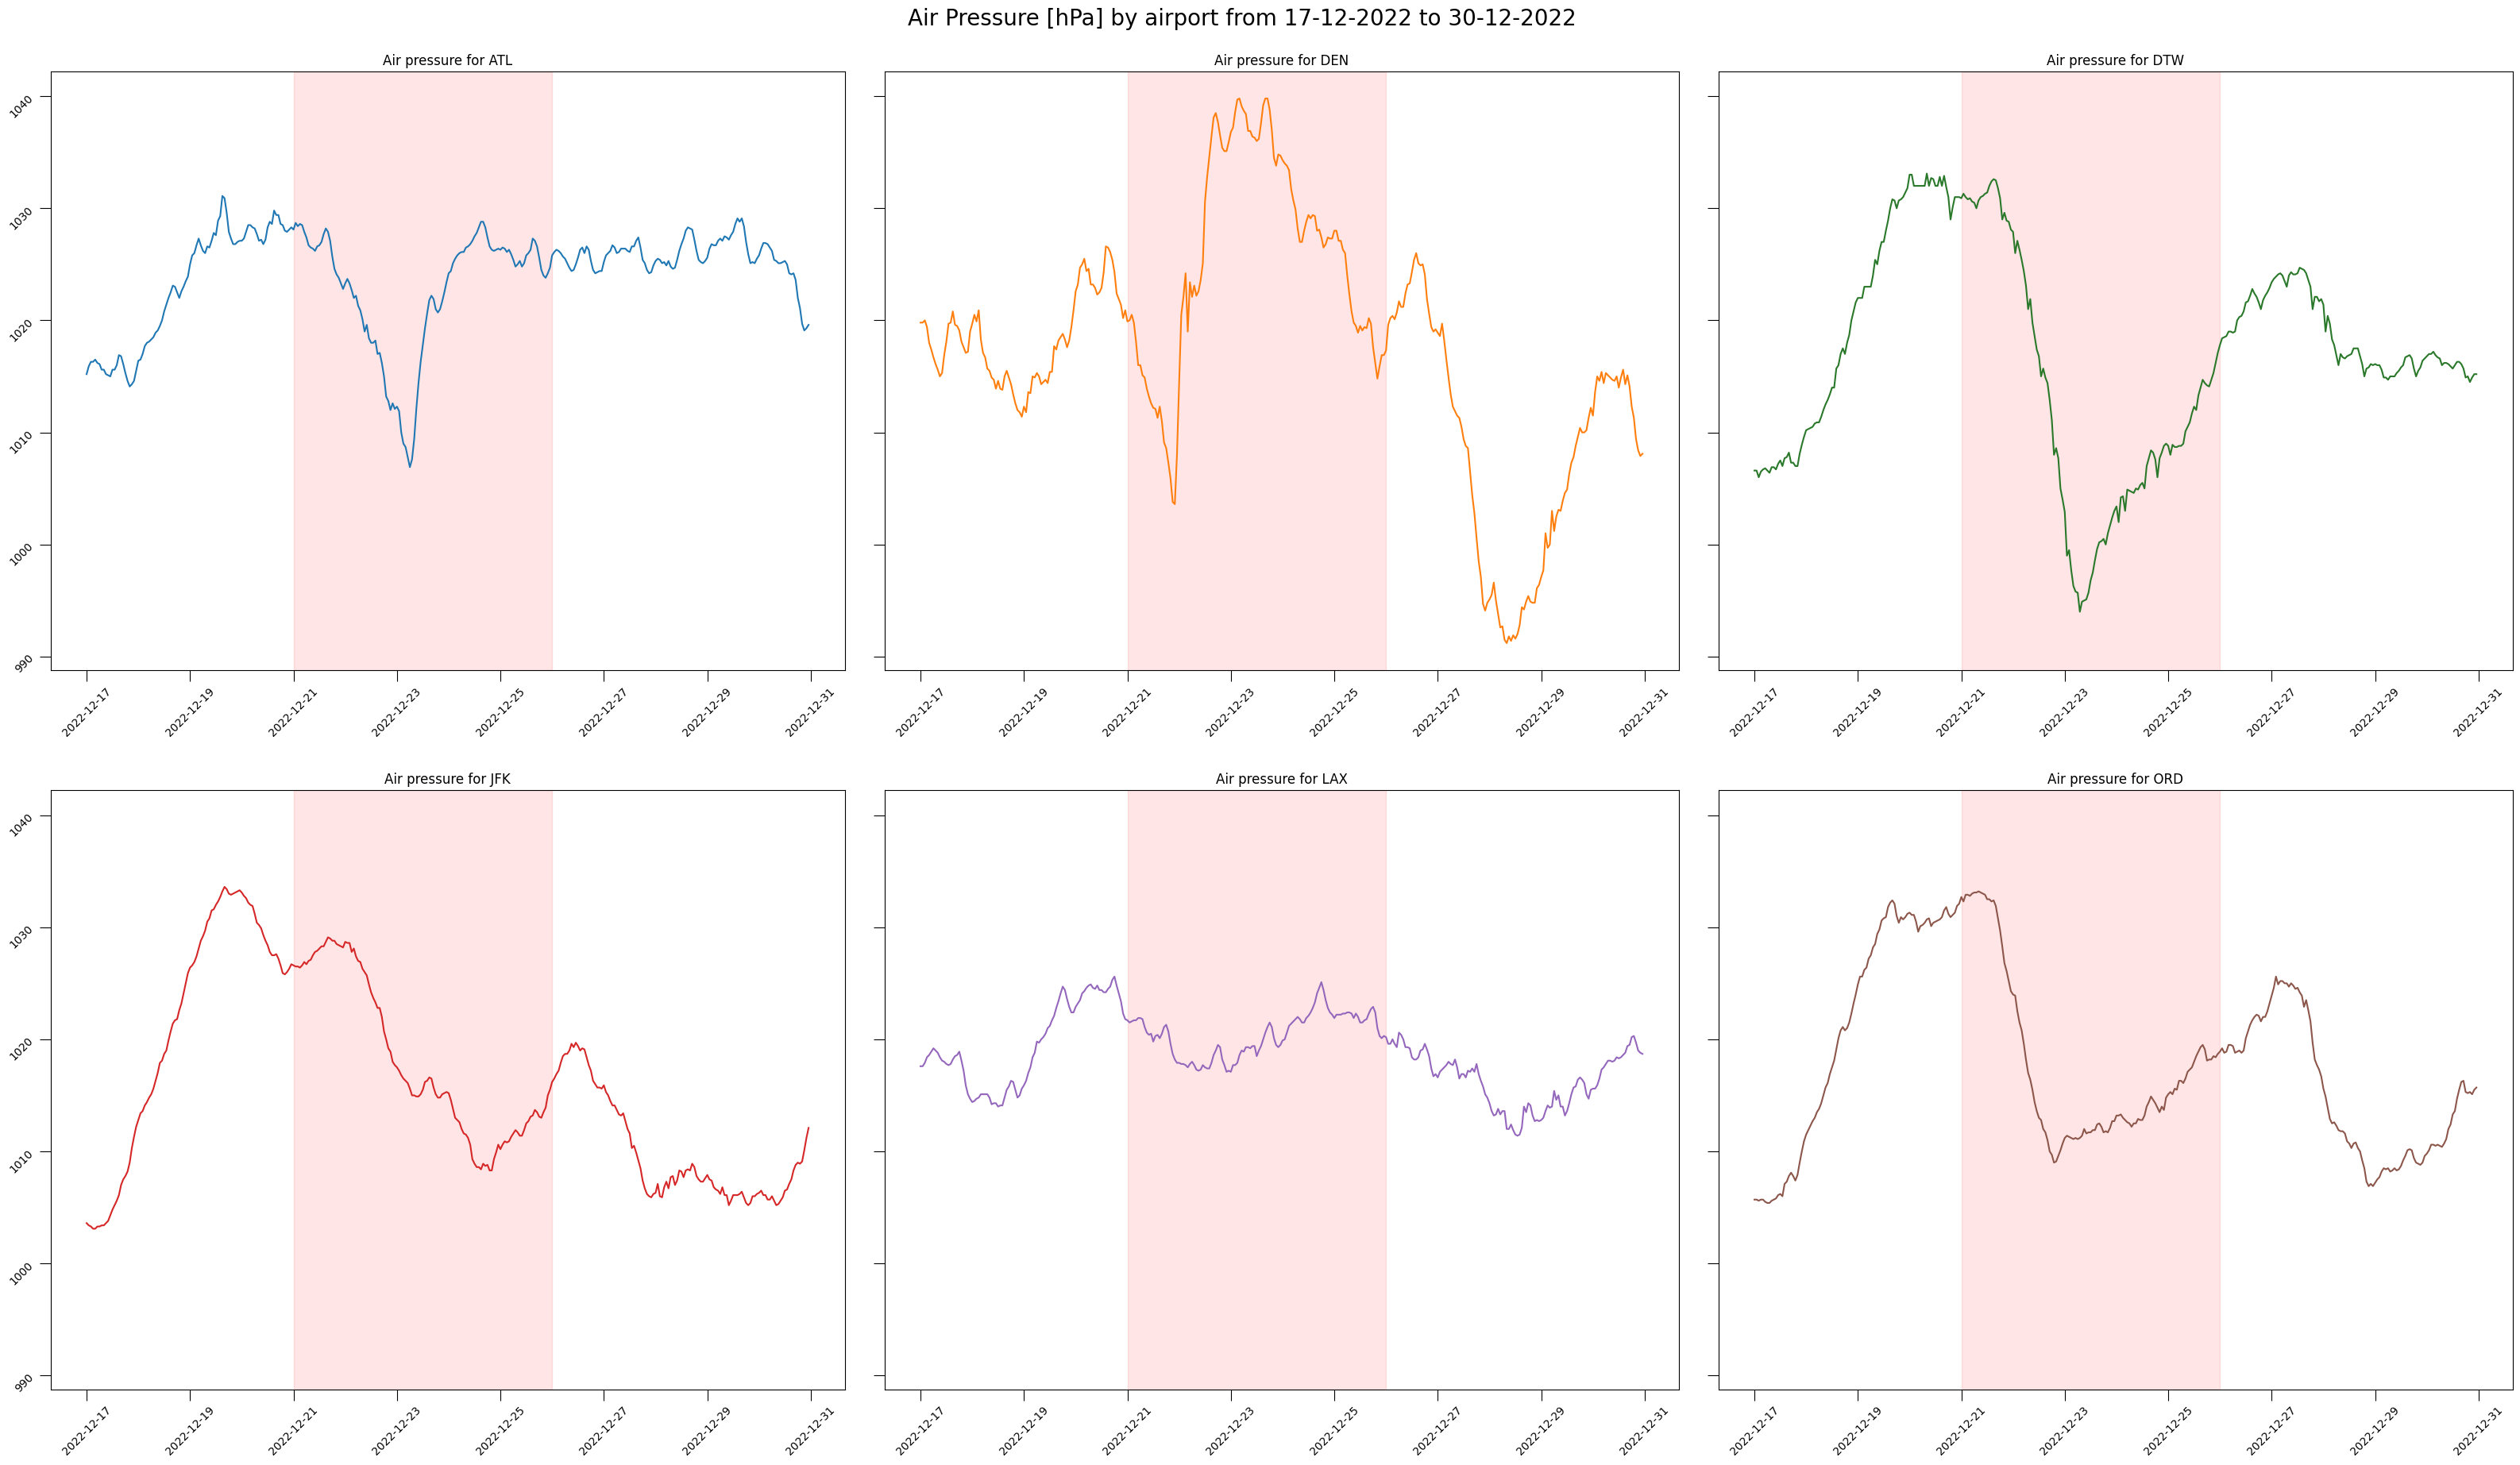

In [101]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
#plt.ylim(0,1000)
i = 0
start_date = '2022-12-17'
end_date = '2022-12-30'
plt.suptitle('Air Pressure [hPa] by airport from 17-12-2022 to 30-12-2022', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
        df_int = df_int.sort_values(by='timestamp')
        ax[a][b].plot(df_int['timestamp'],df_int['pressure_hpa'], color = color_mapping[x])
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Air pressure for {x}')
        ax[a][b].axvspan("2022-12-21", "2022-12-26", color='red', alpha=0.1, label='Winter Storm Elliott')
        display()
        i += 1

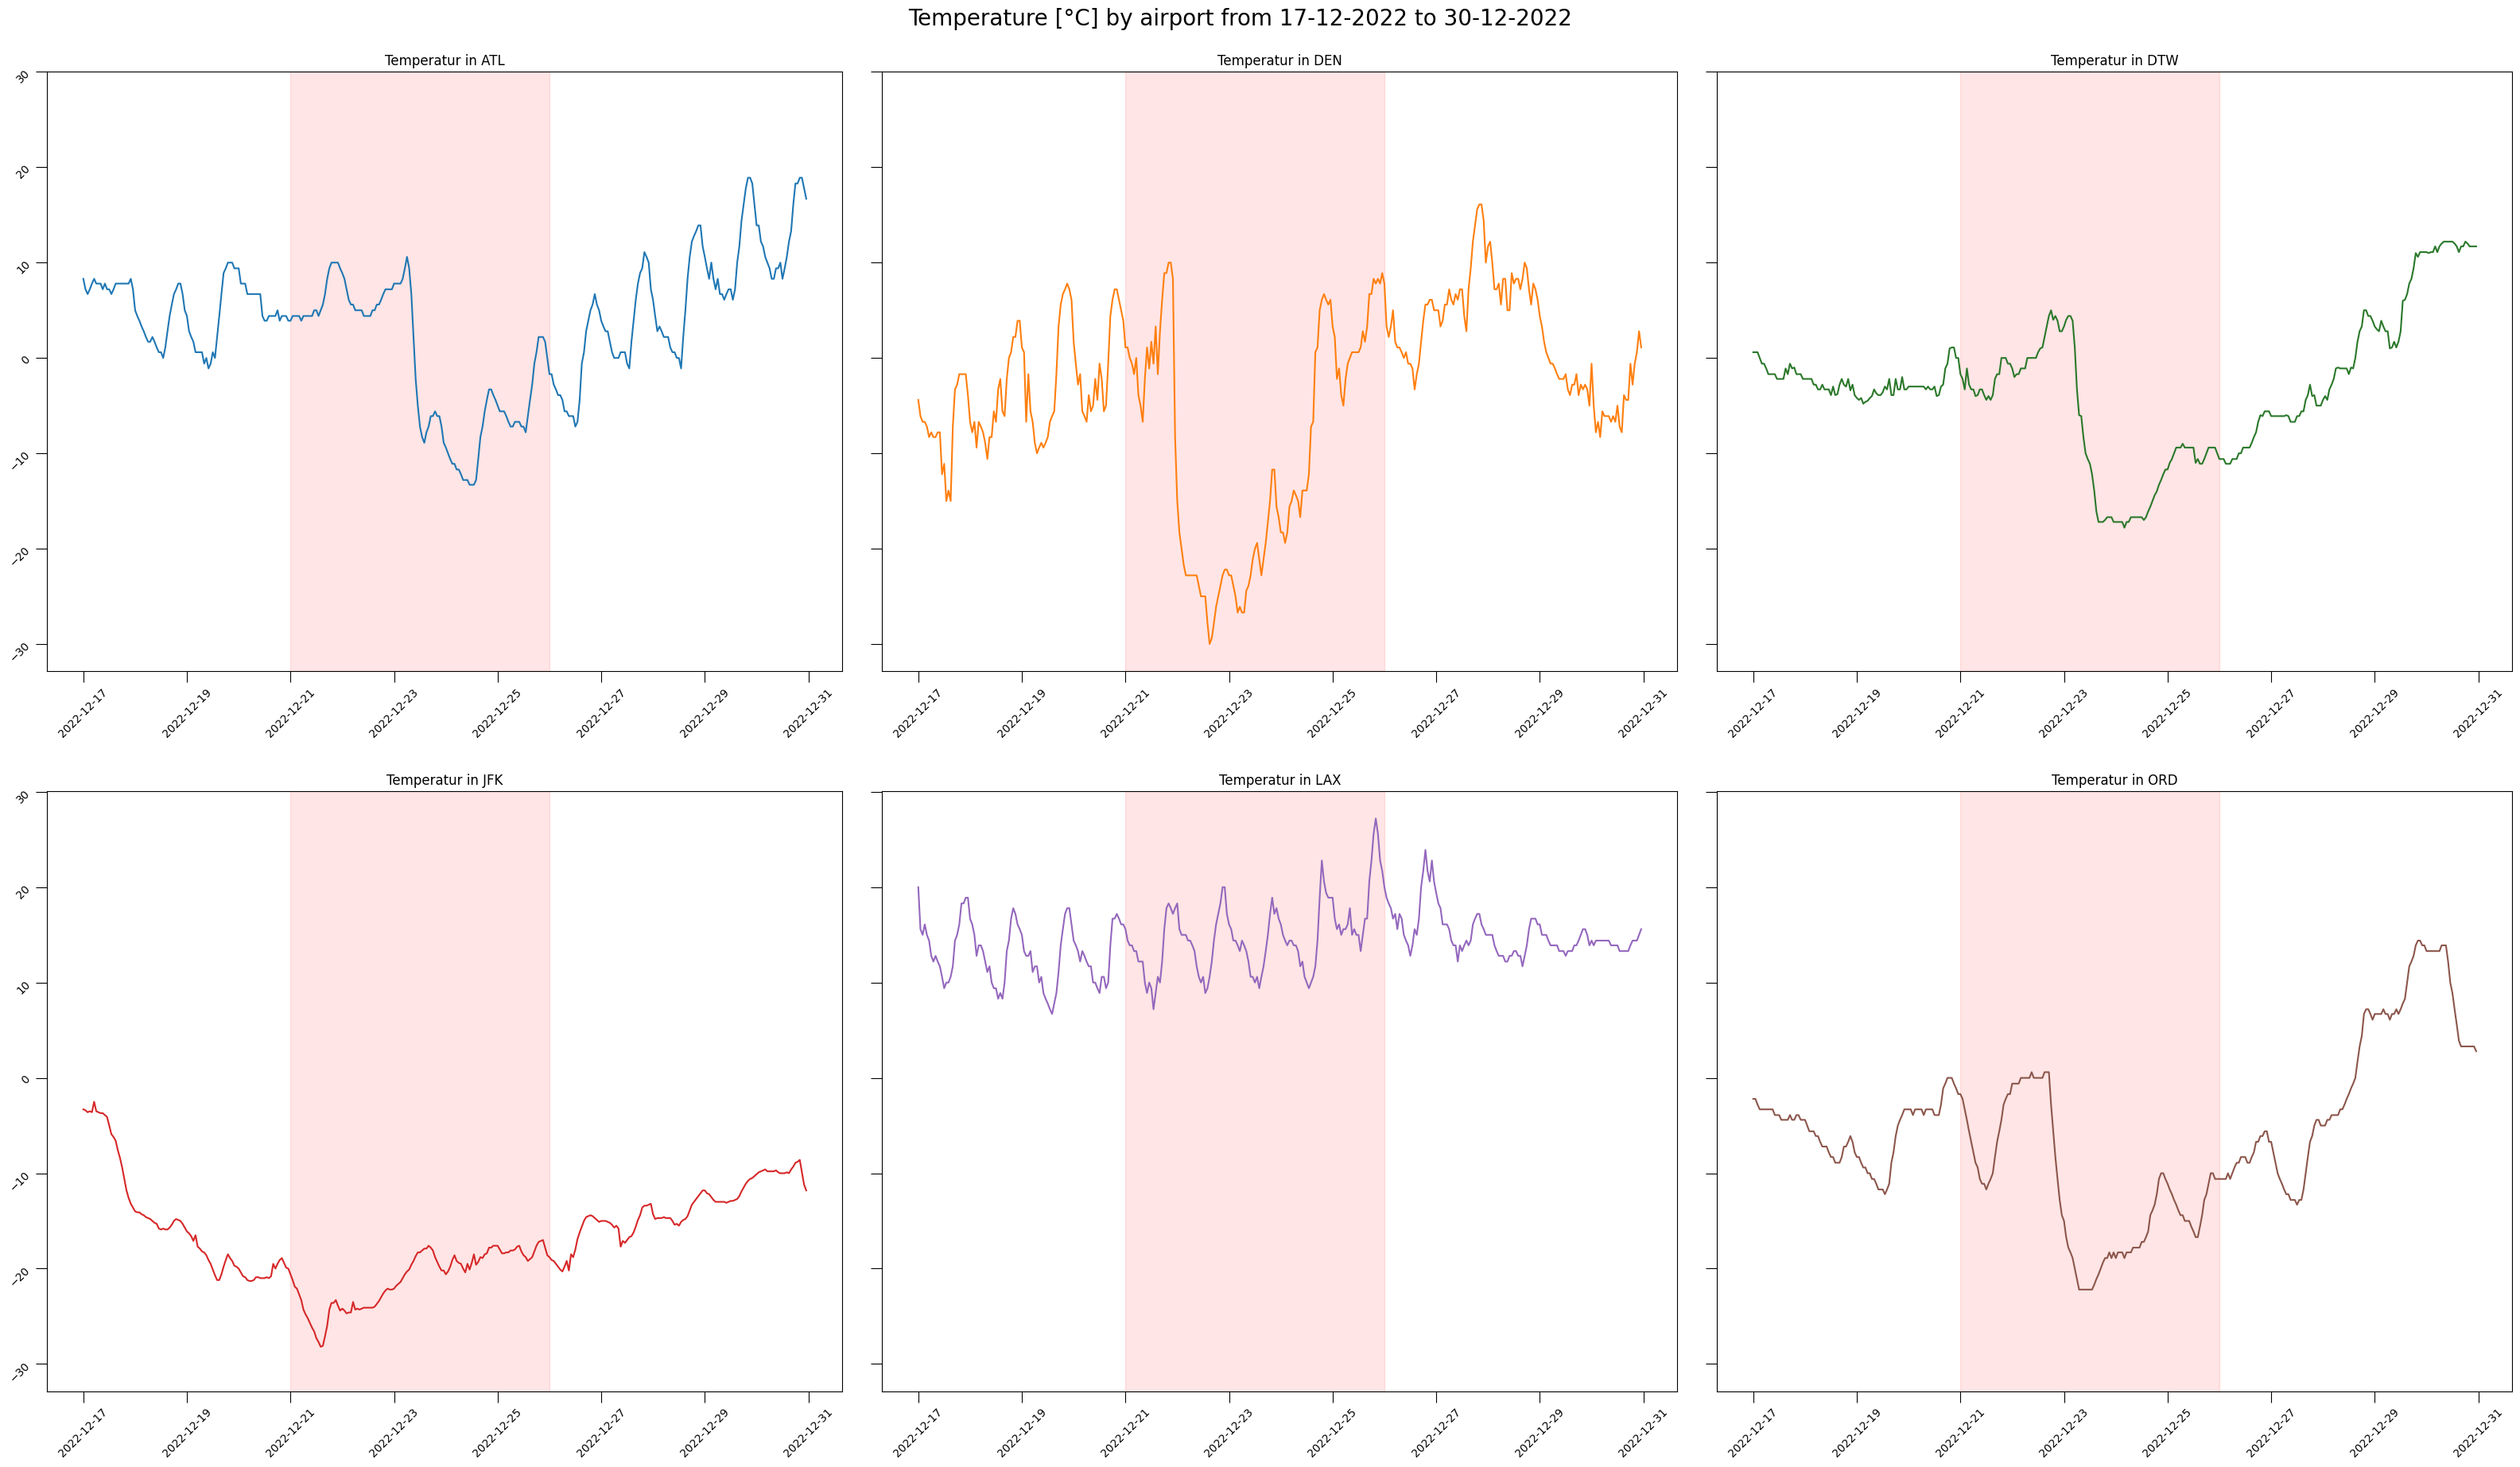

In [98]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
#plt.ylim(0,1000)
i = 0
start_date = '2022-12-17'
end_date = '2022-12-30'
plt.suptitle('Temperature [°C] by airport from 17-12-2022 to 30-12-2022', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
        df_int = df_int.sort_values(by='timestamp')
        ax[a][b].plot(df_int['timestamp'],df_int['temp_c'], color = color_mapping[x])
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Temperatur in {x}')
        ax[a][b].axvspan("2022-12-21", "2022-12-26", color='red', alpha=0.1, label='Winter Storm Elliott')
        display()
        i += 1

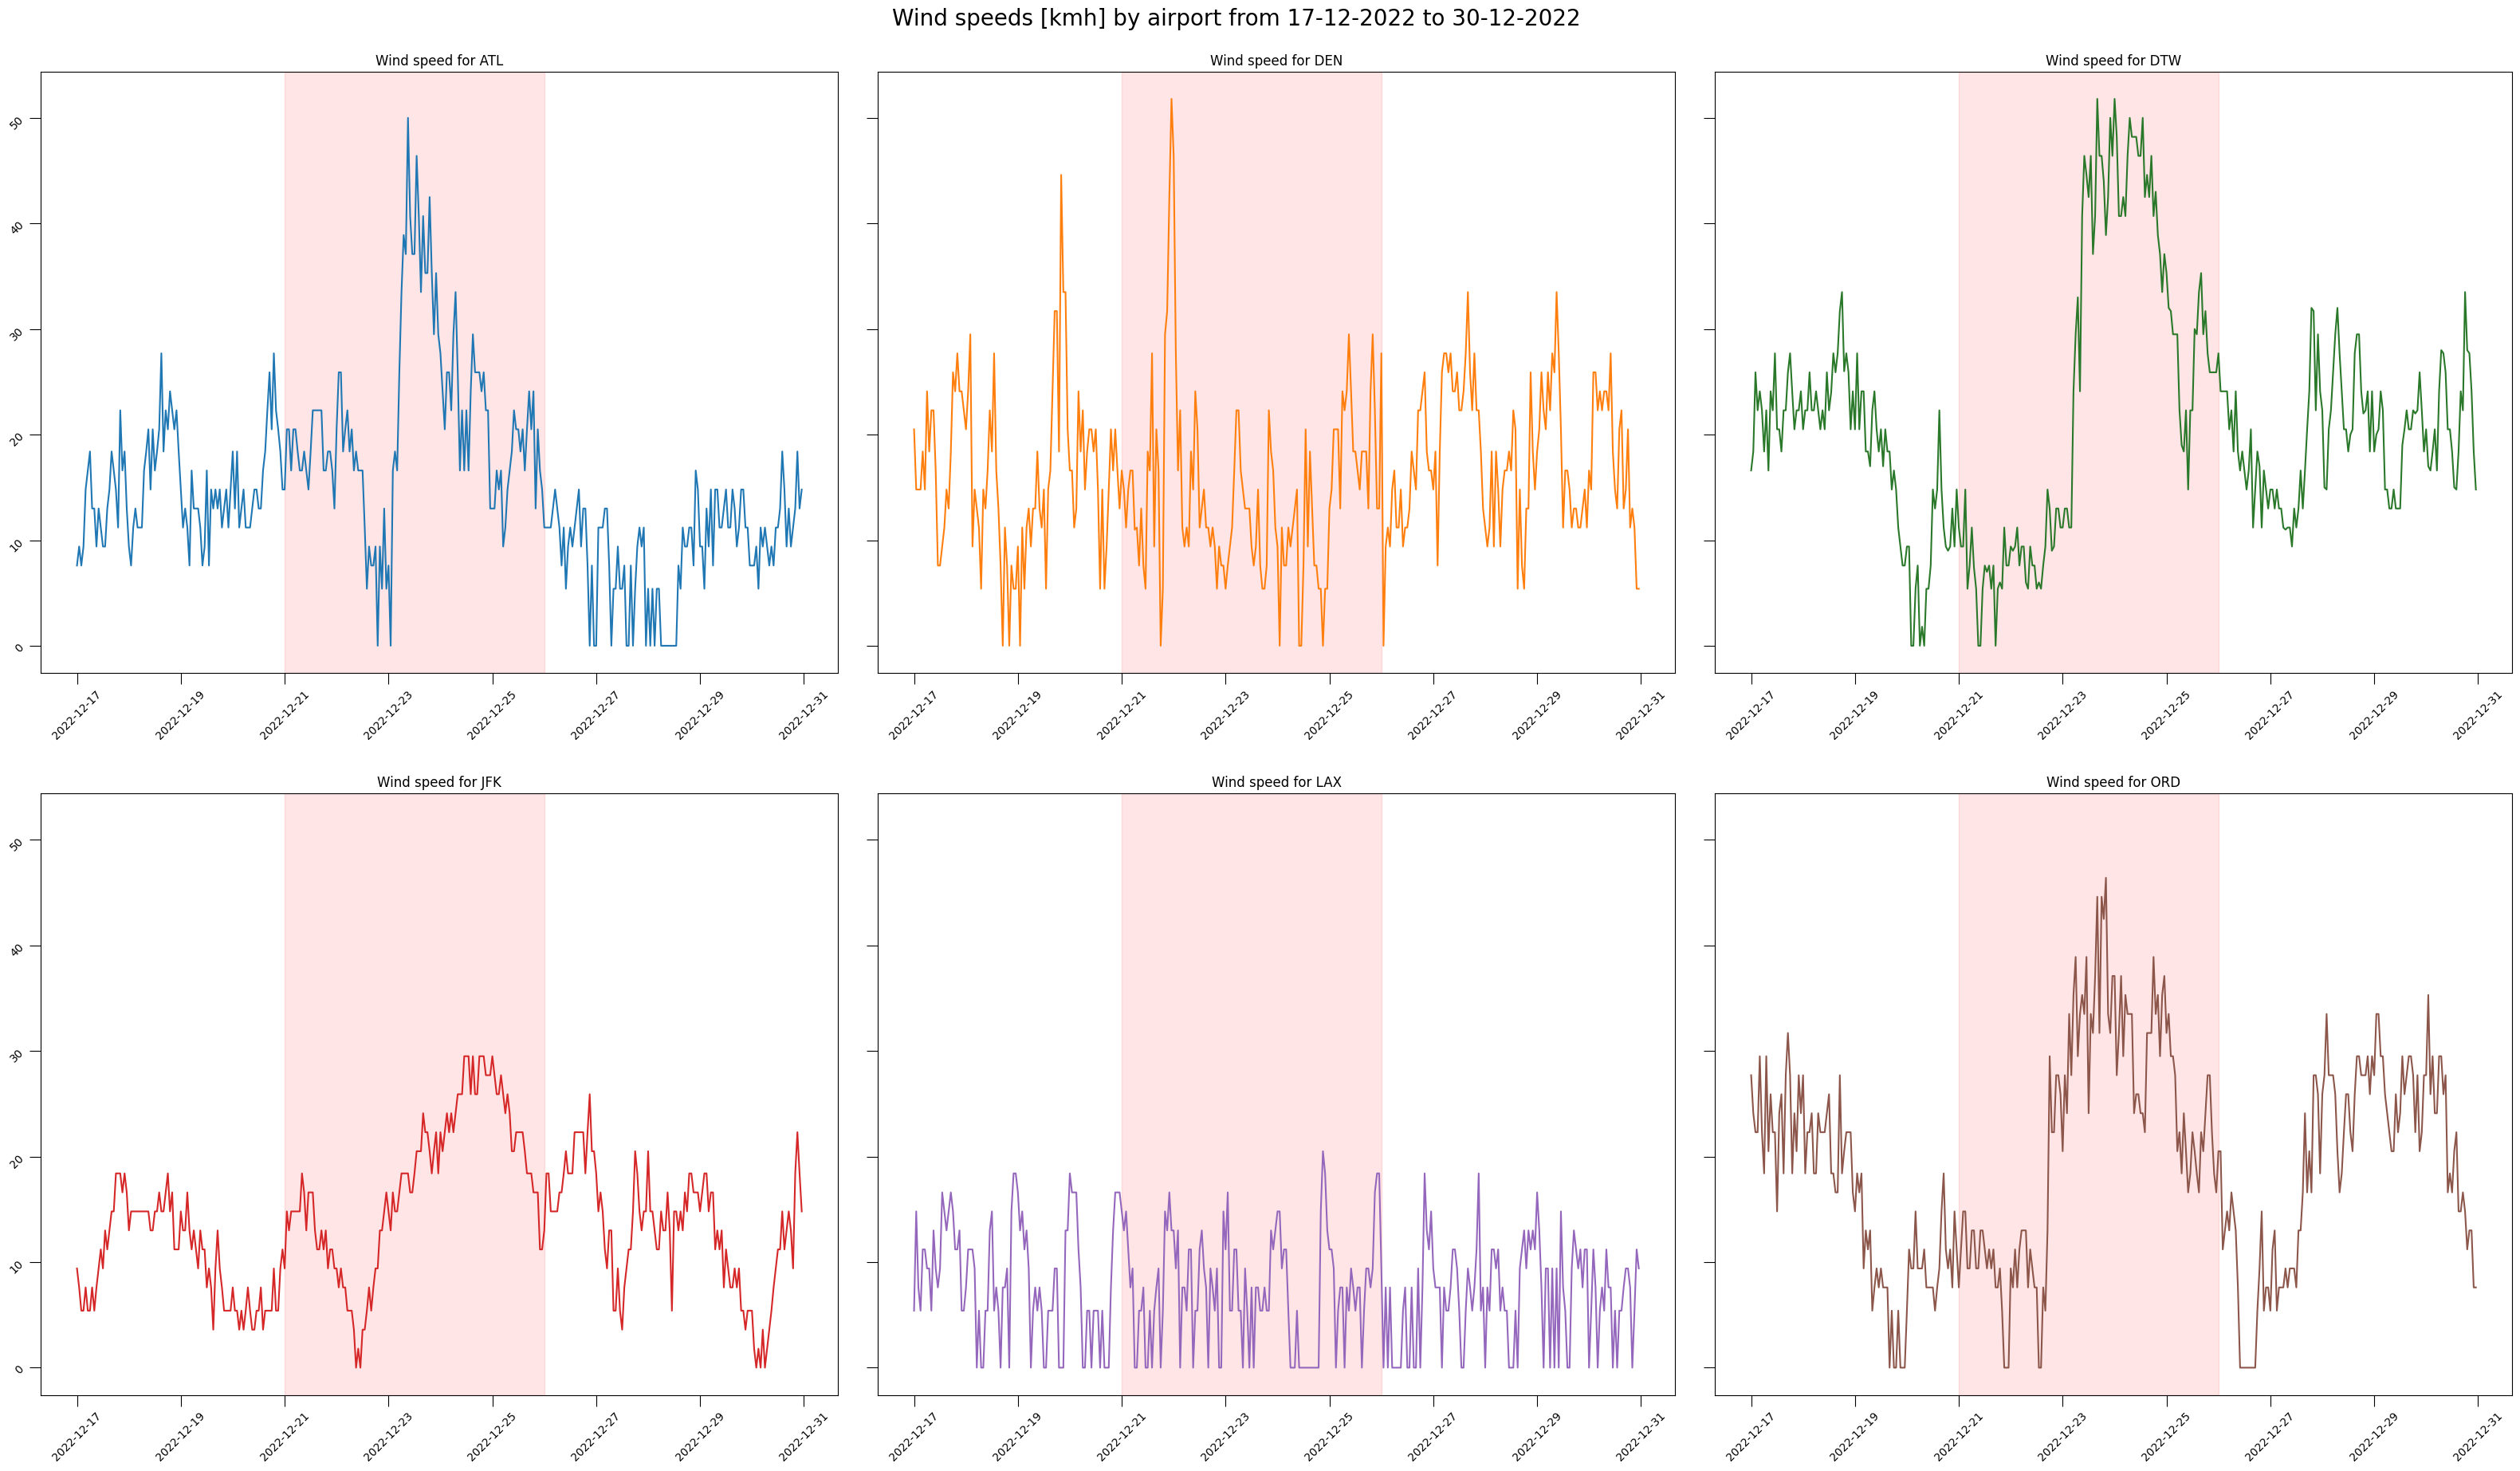

In [99]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
#plt.ylim(0,1000)
i = 0
start_date = '2022-12-17'
end_date = '2022-12-30'
plt.suptitle('Wind speeds [kmh] by airport from 17-12-2022 to 30-12-2022', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
        df_int = df_int.sort_values(by='timestamp')
        ax[a][b].plot(df_int['timestamp'],df_int['wind_speed_kmh'], color = color_mapping[x])
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Wind speed for {x}')
        ax[a][b].axvspan("2022-12-21", "2022-12-26", color='red', alpha=0.1, label='Winter Storm Elliott')
        display()
        i += 1

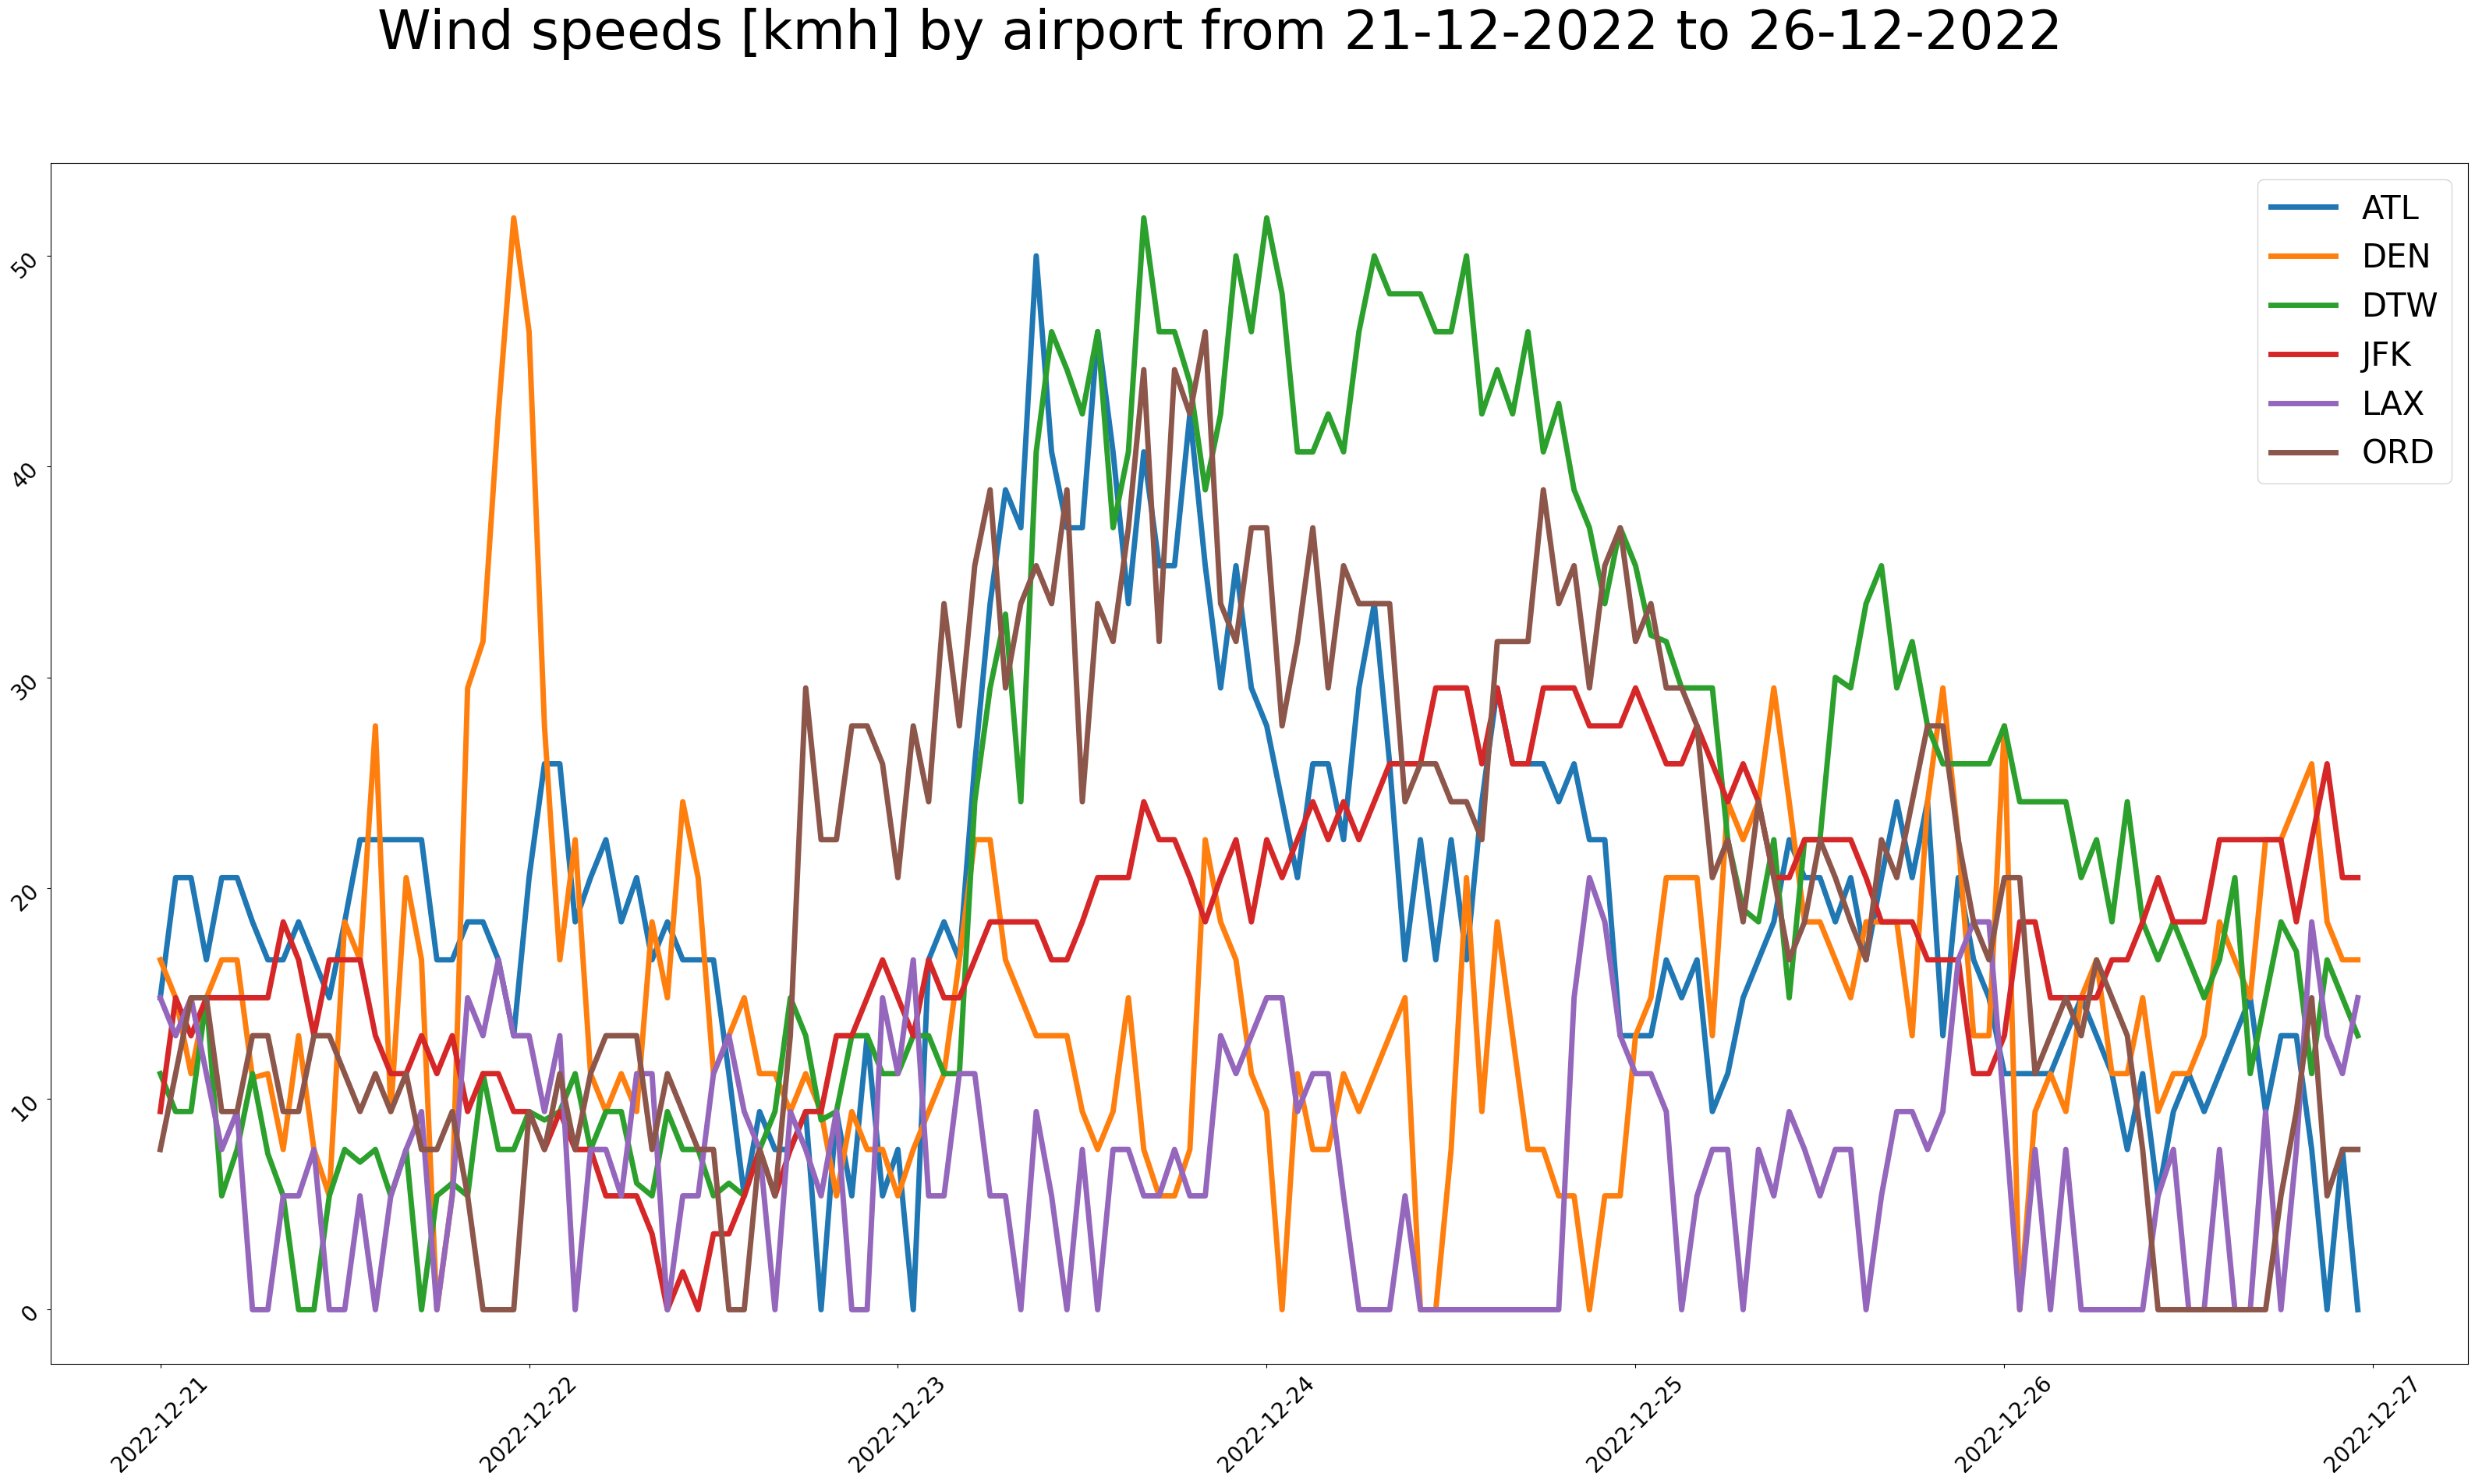

In [54]:
start_date = '2022-12-21'
end_date = '2022-12-26'
plt.figure(figsize= (40,20))
plt.suptitle('Wind speeds [kmh] by airport from 21-12-2022 to 26-12-2022', fontsize=50)
for x in airports:
    df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
    df_int = df_int.sort_values(by='timestamp')
    plt.plot(df_int['timestamp'],df_int['wind_speed_kmh'], linewidth = 5)
plt.tick_params(labelrotation=45, labelsize = 20)
plt.legend(airports, fontsize= 30)
display()


Average dwell time by day and airport

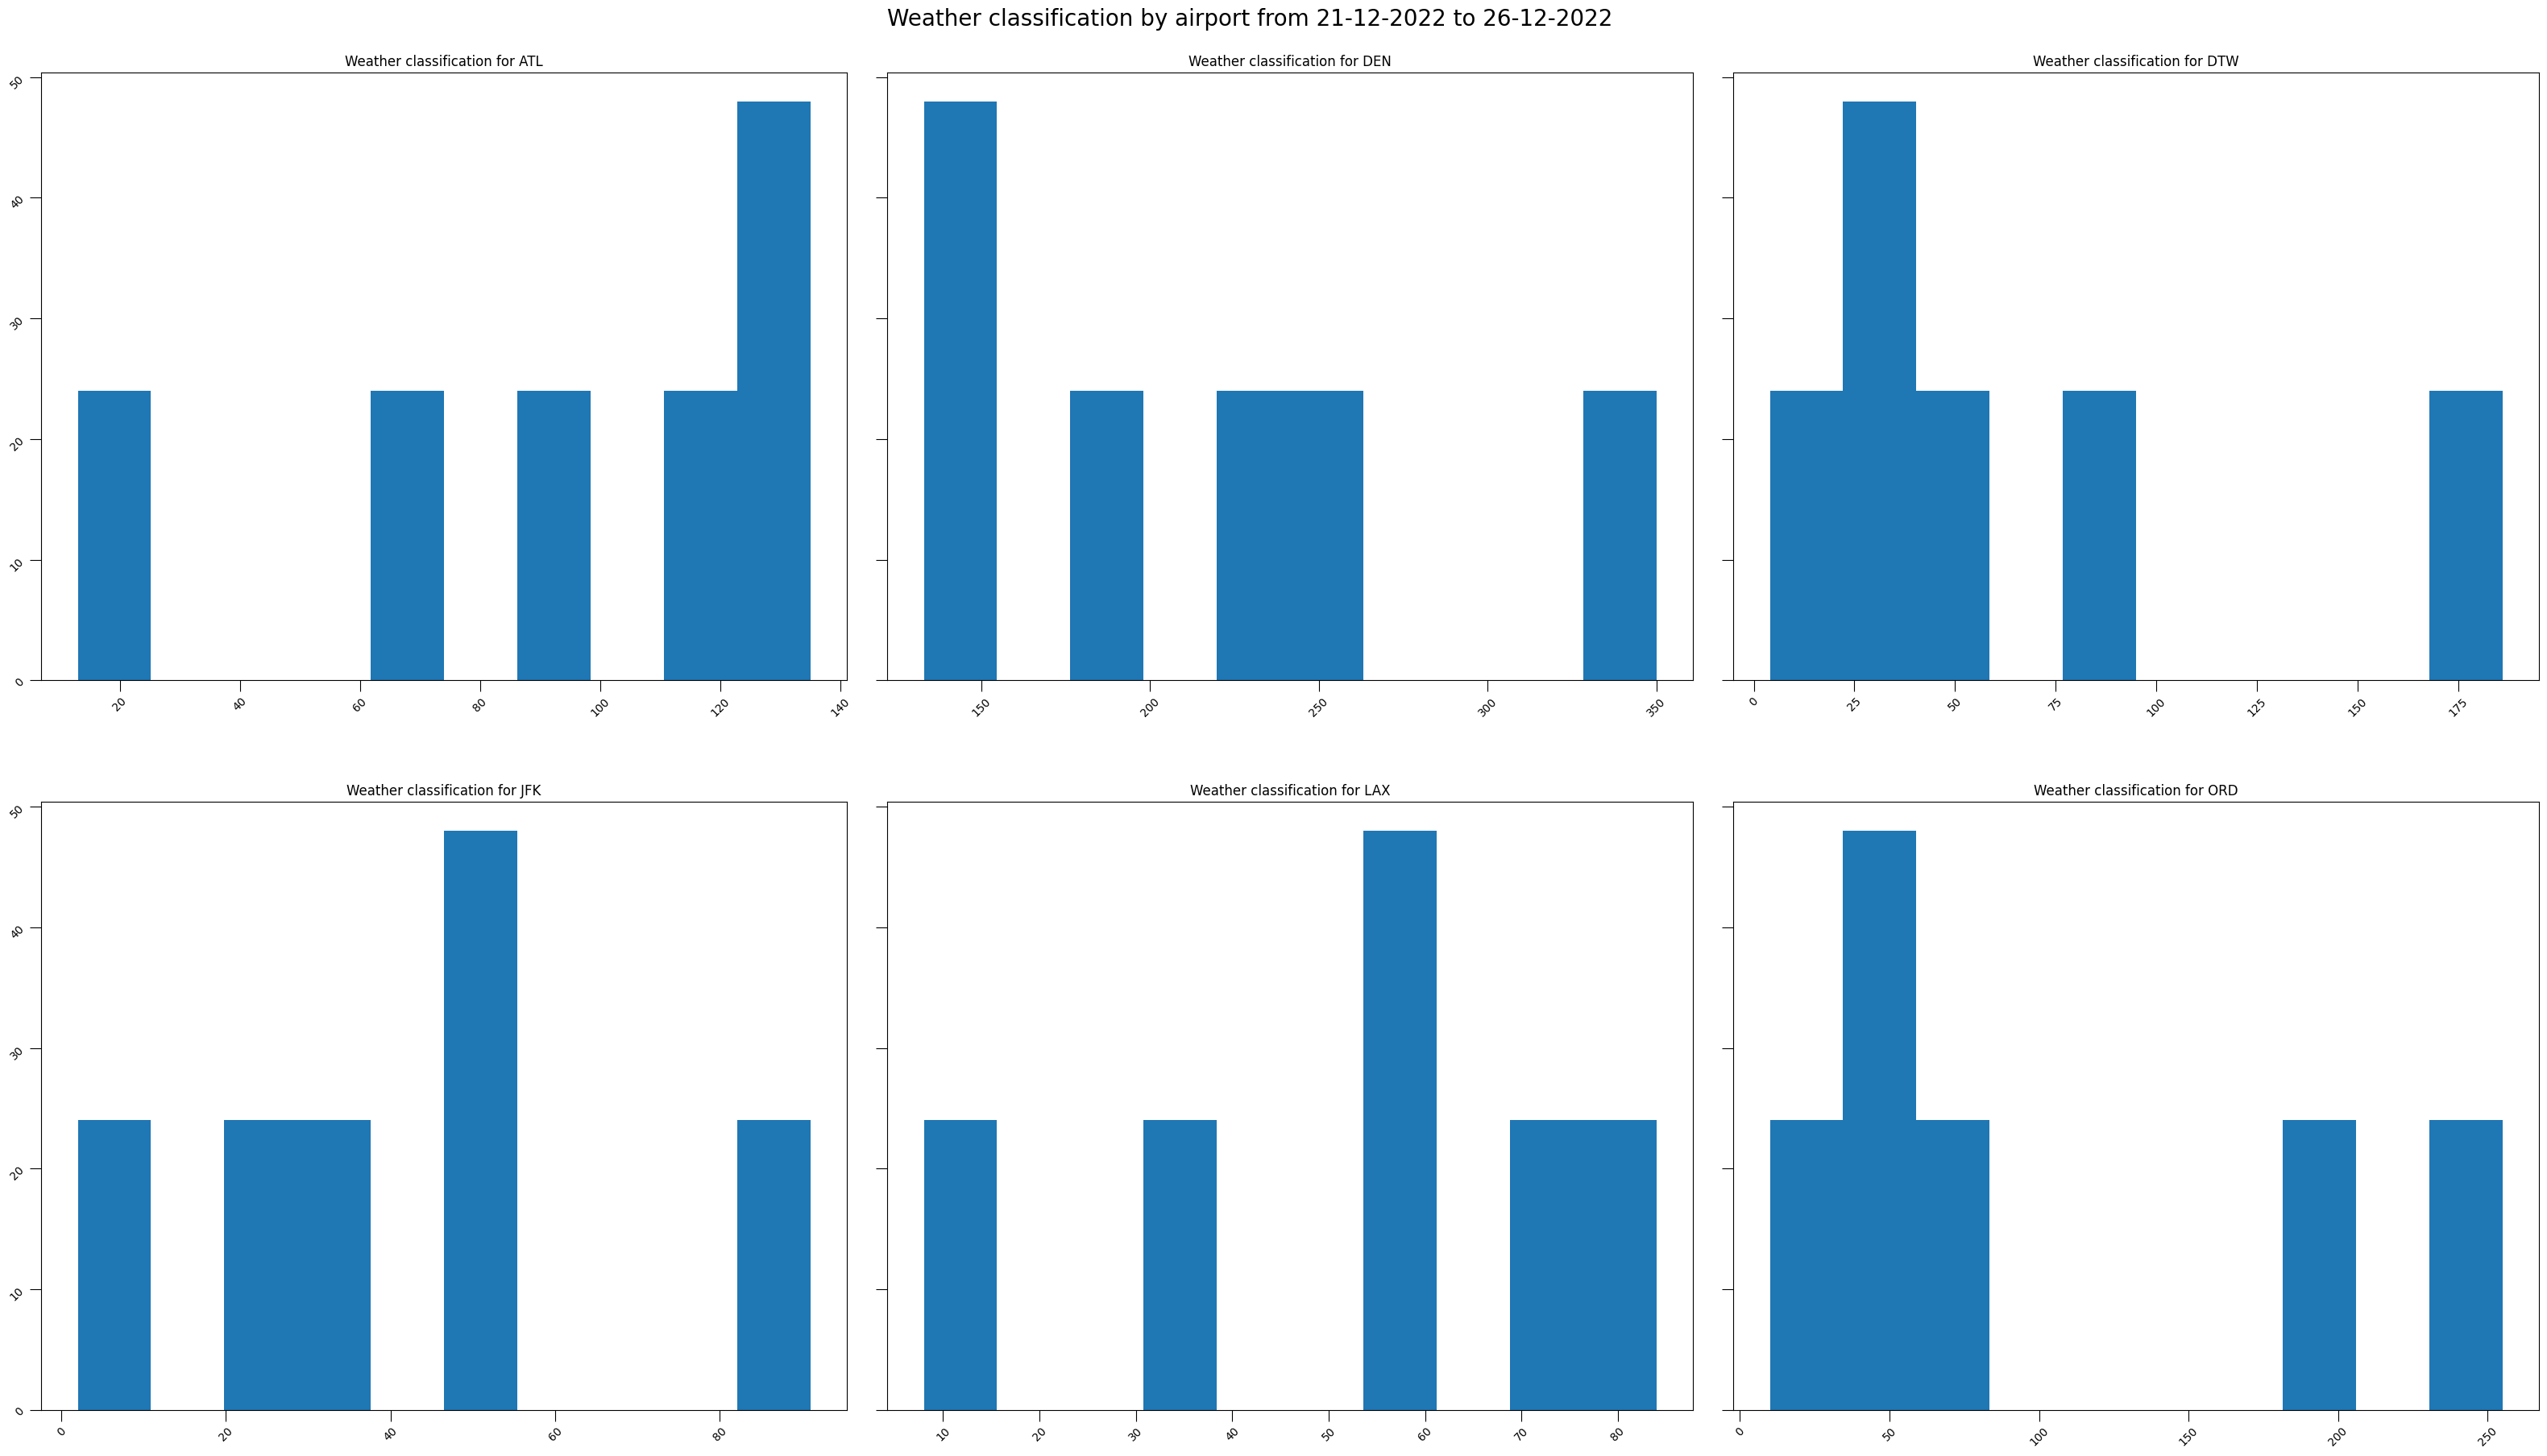

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
#plt.ylim(0,1000)
i = 0
start_date = '2022-12-21'
end_date = '2022-12-26'
plt.suptitle('Weather classification by airport from 21-12-2022 to 26-12-2022', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
        ax[a][b].hist(x=df_int['total_canceled_dep'])
        #ax[a][b].tick_params(labelrotation=45, size = 10)
        #ax[a][b].set_title(f'Weather classification for {x}')
        display()
        i += 1

In [ ]:
x = airports[i]
start_date = '2022-12-21'
end_date = '2022-12-26'
df_int = df_flights[(df_flights['origin'] == x) & (df_flights['flight_date'] >= parser.parse(start_date).date()) & (df_flights['flight_date'] <= parser.parse(end_date).date())]
plt.hist(df_flights['avg_de'])


In [ ]:
color_mapping = {
 'ATL': '#1f77b4', # blue
 'DEN': '#ff7f0e', # orange
 'DTW': "#2A782A", # green
 'JFK': '#d62728', # red
 'LAX': '#9467bd', # purple
 'ORD': '#8c564b'  # brown
}

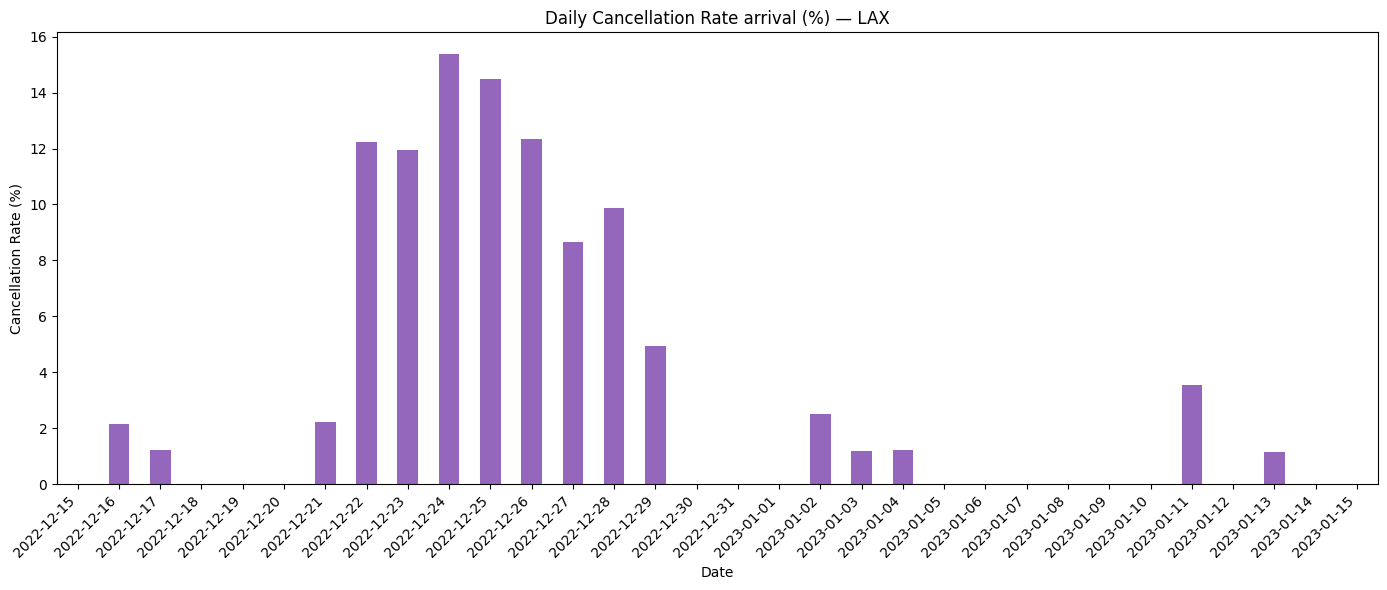

In [84]:
start_date = '2022-12-15'
end_date = '2023-01-15'

df_time_2 = df_weather[(df_weather['faa'] == 'LAX')&
    (df_weather['date'] >= parser.parse(start_date).date()) &
    (df_weather['date'] <= parser.parse(end_date).date())
]


df_stats = (
    df_time_2[
        ['faa', 'date',
         'total_planed_dep', 'total_planed_arr',
         'total_canceled_dep', 'total_canceled_arr']
    ]
    .drop_duplicates(subset=['faa', 'date'])
)


df_stats['total_planned']   = df_stats['total_planed_arr']
df_stats['total_canceled']  = df_stats['total_canceled_arr']


daily = df_stats.groupby('date').agg(
    daily_planned   = ('total_planned',  'sum'),
    daily_canceled  = ('total_canceled', 'sum')
)

daily['cancel_rate_pct'] = daily['daily_canceled'] / daily['daily_planned'] * 100
my_color = '#9467bd'


plt.figure(figsize=(14,6))
daily['cancel_rate_pct'].plot(kind='bar',color = my_color)
plt.title('Daily Cancellation Rate arrival (%) — LAX')
plt.xlabel('Date')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()